# en este notebook pondre la variable dummy avenida_cerrada donde 1 si alguna avenida durante ese tiempo, 0 si no. la informacion se tomó de noticias

In [63]:
import pandas as pd

df = pd.read_excel('../datos/datos_imputados/SUROESTE2_IMPUTADO.xlsx')

In [64]:
df = df[['date','CO', 'NO', 'NO2','SO2', 'PM10', 'PM2.5']]

In [41]:
df.dtypes

date     datetime64[ns]
CO              float64
NO              float64
NO2             float64
PM10            float64
PM2.5           float64
dtype: object

In [65]:
df = df.set_index('date')

In [66]:
cols = ["CO", "PM10", "PM2.5", "SO2", "NO2"] 

df_rolling = df[cols].rolling('24h').mean().add_suffix('_24h')
df = pd.concat([df, df_rolling], axis=1)

df_dia = df.resample('D').mean(numeric_only=True)


In [67]:
df_dia.reset_index(inplace=True)

In [68]:
df_dia

,date,CO,NO,NO2,SO2,PM10,PM2.5,CO_24h,PM10_24h,PM2.5_24h,SO2_24h,NO2_24h
0,2021-01-01,3.569167,5.404167,18.370833,3.690000,58.458333,13.800000,3.646240,68.879958,15.173911,3.261949,17.693589
1,2021-01-02,3.542083,4.691667,18.204167,4.343333,47.708333,12.700000,3.492066,47.692708,12.181944,4.283750,18.189236
2,2021-01-03,3.565833,3.304167,16.783333,3.664167,53.666667,15.791667,3.561944,51.914931,13.984028,3.917153,16.335764
3,2021-01-04,3.556667,4.514167,20.630833,4.115000,47.041667,14.741667,3.551233,50.633681,15.681944,3.878611,18.621424
4,2021-01-05,3.583750,4.956667,20.422500,3.893333,48.958333,15.866667,3.587205,47.039931,14.723958,4.110174,21.953993
...,...,...,...,...,...,...,...,...,...,...,...,...
1637,2025-06-26,0.340000,5.429167,10.512500,4.241667,34.958333,12.766667,0.321701,37.071181,13.335069,3.813194,9.620486
1638,2025-06-27,0.417917,6.054167,12.041667,3.695833,35.166667,13.391667,0.340903,34.092014,12.910069,3.931424,10.461458
1639,2025-06-28,0.282500,4.937500,8.066667,3.445833,30.875000,12.050000,0.371493,34.251736,12.882292,3.512153,10.590278
1640,2025-06-29,0.252917,4.141667,6.875000,4.000000,28.916667,10.758333,0.260937,29.690972,11.484375,3.726562,7.000347


In [69]:


cierres = [
    # Av. Constitución exprés (sondeos)
    {"inicio": "2023-04-11", "fin": "2023-07-11"},  # asumimos +2 meses
    
    # Puente Pedro Martínez (1er cierre total)
    {"inicio": "2024-02-14", "fin": "2025-01-19"},
    
    # Puente Pedro Martínez (nuevo cierre)
    {"inicio": "2025-08-01", "fin": "2025-10-01"},  # asumimos +2 meses
    
    # Av. San Jerónimo
    {"inicio": "2024-01-02", "fin": "2025-08-15"},
    
    # Av. Constitución exprés (Colón ↔ Pabellón M)
    {"inicio": "2025-07-07", "fin": "2025-08-31"},
]

df_dia['avenida_cerrada'] = 0

for c in cierres:
    inicio = pd.to_datetime(c["inicio"])
    fin = pd.to_datetime(c["fin"])
    df_dia.loc[(df_dia['date'] >= inicio) & (df_dia['date'] <= fin), 'avenida_cerrada'] = 1


In [70]:
df_dia.avenida_cerrada.value_counts()

avenida_cerrada
0    1004
1     638
Name: count, dtype: int64

In [71]:
df_dia

,date,CO,NO,NO2,SO2,PM10,PM2.5,CO_24h,PM10_24h,PM2.5_24h,SO2_24h,NO2_24h,avenida_cerrada
0,2021-01-01,3.569167,5.404167,18.370833,3.690000,58.458333,13.800000,3.646240,68.879958,15.173911,3.261949,17.693589,0
1,2021-01-02,3.542083,4.691667,18.204167,4.343333,47.708333,12.700000,3.492066,47.692708,12.181944,4.283750,18.189236,0
2,2021-01-03,3.565833,3.304167,16.783333,3.664167,53.666667,15.791667,3.561944,51.914931,13.984028,3.917153,16.335764,0
3,2021-01-04,3.556667,4.514167,20.630833,4.115000,47.041667,14.741667,3.551233,50.633681,15.681944,3.878611,18.621424,0
4,2021-01-05,3.583750,4.956667,20.422500,3.893333,48.958333,15.866667,3.587205,47.039931,14.723958,4.110174,21.953993,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,2025-06-26,0.340000,5.429167,10.512500,4.241667,34.958333,12.766667,0.321701,37.071181,13.335069,3.813194,9.620486,1
1638,2025-06-27,0.417917,6.054167,12.041667,3.695833,35.166667,13.391667,0.340903,34.092014,12.910069,3.931424,10.461458,1
1639,2025-06-28,0.282500,4.937500,8.066667,3.445833,30.875000,12.050000,0.371493,34.251736,12.882292,3.512153,10.590278,1
1640,2025-06-29,0.252917,4.141667,6.875000,4.000000,28.916667,10.758333,0.260937,29.690972,11.484375,3.726562,7.000347,1


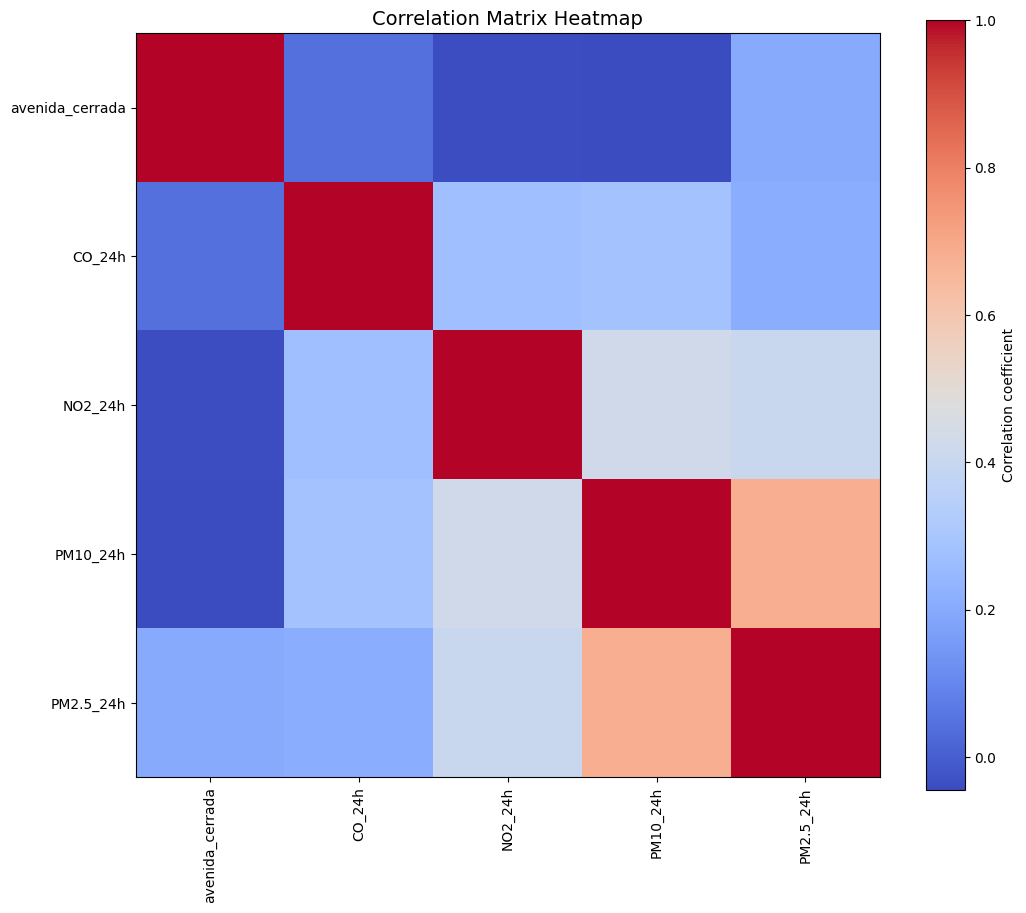

In [74]:
import matplotlib.pyplot as plt
corr_matrix = df_dia[['avenida_cerrada',
       'CO_24h', 'NO2_24h', 'PM10_24h',
       'PM2.5_24h']].corr()

plt.figure(figsize=(12,10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

In [75]:
df_dia.columns

Index(['date', 'CO', 'NO', 'NO2', 'SO2', 'PM10', 'PM2.5', 'CO_24h', 'PM10_24h',
       'PM2.5_24h', 'SO2_24h', 'NO2_24h', 'avenida_cerrada'],
      dtype='object')

In [77]:
df_dia[['avenida_cerrada','CO_24h', 'PM10_24h',
       'PM2.5_24h']].corr()

,avenida_cerrada,CO_24h,PM10_24h,PM2.5_24h
avenida_cerrada,1.000000,0.043066,-0.045112,0.203706
CO_24h,0.043066,1.000000,0.286260,0.209291
PM10_24h,-0.045112,0.286260,1.000000,0.679284
PM2.5_24h,0.203706,0.209291,0.679284,1.000000


In [78]:
df_dia

,date,CO,NO,NO2,SO2,PM10,PM2.5,CO_24h,PM10_24h,PM2.5_24h,SO2_24h,NO2_24h,avenida_cerrada
0,2021-01-01,3.569167,5.404167,18.370833,3.690000,58.458333,13.800000,3.646240,68.879958,15.173911,3.261949,17.693589,0
1,2021-01-02,3.542083,4.691667,18.204167,4.343333,47.708333,12.700000,3.492066,47.692708,12.181944,4.283750,18.189236,0
2,2021-01-03,3.565833,3.304167,16.783333,3.664167,53.666667,15.791667,3.561944,51.914931,13.984028,3.917153,16.335764,0
3,2021-01-04,3.556667,4.514167,20.630833,4.115000,47.041667,14.741667,3.551233,50.633681,15.681944,3.878611,18.621424,0
4,2021-01-05,3.583750,4.956667,20.422500,3.893333,48.958333,15.866667,3.587205,47.039931,14.723958,4.110174,21.953993,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,2025-06-26,0.340000,5.429167,10.512500,4.241667,34.958333,12.766667,0.321701,37.071181,13.335069,3.813194,9.620486,1
1638,2025-06-27,0.417917,6.054167,12.041667,3.695833,35.166667,13.391667,0.340903,34.092014,12.910069,3.931424,10.461458,1
1639,2025-06-28,0.282500,4.937500,8.066667,3.445833,30.875000,12.050000,0.371493,34.251736,12.882292,3.512153,10.590278,1
1640,2025-06-29,0.252917,4.141667,6.875000,4.000000,28.916667,10.758333,0.260937,29.690972,11.484375,3.726562,7.000347,1


In [79]:
df_dia.to_excel('../datos/datos_dia_avenidas/SUROESTE2_AVENIDAS.xlsx', index=False)

In [ ]:
df_dia

,date,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,...,TOUT_24h,WSR_24h,WDR_24h,WDV_24h,Calidad_PM10_24h,Calidad_PM2.5_24h,Calidad_O3_24h,Calidad_CO_24h,Calidad_SO2_24h,Calidad_NO2_24h
0,2021-01-01,4.675417,10.395833,20.309167,30.540833,23.000000,47.291667,31.737917,712.492500,0.0,...,7.267123,4.829035,137.800132,145.983095,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1,2021-01-02,4.686250,9.810000,18.176667,27.085000,27.725000,41.916667,22.372417,716.191667,0.0,...,9.748108,4.025347,126.085069,116.859722,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
2,2021-01-03,4.917500,18.946667,24.049167,41.128333,27.508333,70.625000,41.418417,713.975000,0.0,...,12.859340,3.352083,160.989583,148.380208,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
3,2021-01-04,5.011250,12.264167,22.066667,31.747500,28.100000,65.666667,22.968750,713.204167,0.0,...,16.398976,3.299132,201.380208,125.755208,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
4,2021-01-05,4.950833,12.531667,19.925000,29.960000,27.708333,53.833333,20.345000,712.741667,0.0,...,18.362135,3.580035,186.590278,122.693056,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1637,2025-06-26,1.240000,10.775000,6.450000,9.891667,30.500000,29.000000,12.368750,711.558333,0.0,...,27.385625,11.893403,67.734375,91.739931,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1638,2025-06-27,1.285833,3.189167,5.775000,8.862500,27.125000,26.791667,13.066667,711.604167,0.0,...,26.712830,10.600521,64.918403,87.198611,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1639,2025-06-28,1.232500,3.069167,3.900000,6.666667,26.458333,24.833333,11.525833,711.995833,0.0,...,26.505122,9.081250,71.036458,77.116667,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación
1640,2025-06-29,1.207083,2.336667,2.675000,4.866667,22.333333,22.958333,8.434583,711.216667,0.0,...,27.165104,10.761111,76.210069,80.399306,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación,Desactivación


In [ ]:
datita = pd.read_excel('../datos/datos_dia_avenidas/CENTRO_AVENIDAS.xlsx')

In [ ]:
datita.columns

Index(['date', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF',
       'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDV', 'avenida_cerrada',
       'CO_24h', 'NO_24h', 'NO2_24h', 'NOX_24h', 'O3_24h', 'PM10_24h',
       'PM2.5_24h', 'PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h'],
      dtype='object')

In [ ]:
data = datita.drop(columns=['PRS_24h', 'RAINF_24h', 'RH_24h', 'SO2_24h', 'SR_24h','O3_24h',
       'TOUT_24h', 'WSR_24h', 'WDR_24h', 'WDV_24h', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF',
       'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDV', 'avenida_cerrada'])


In [ ]:
data.columns = [col.replace('_24h', '') for col in data.columns]


In [ ]:
df = data
df

,date,CO,NO,NO2,NOX,PM10,PM2.5
0,2021-01-01,4.759517,13.779244,21.793775,35.498159,55.803517,43.106937
1,2021-01-02,4.641181,9.113819,17.936736,26.374861,39.743056,22.088799
2,2021-01-03,4.818750,15.440903,22.788576,37.750660,62.619792,35.742743
3,2021-01-04,4.925764,14.499097,22.297014,34.068160,64.576389,30.524396
4,2021-01-05,5.006337,11.945347,21.094583,30.255312,59.173611,21.093750
...,...,...,...,...,...,...,...
1637,2025-06-26,1.231719,19.377257,6.093924,9.612326,29.519097,12.961128
1638,2025-06-27,1.250608,4.870868,5.662674,8.859201,26.857639,11.821337
1639,2025-06-28,1.267778,2.967222,4.861632,7.784375,25.868056,12.209479
1640,2025-06-29,1.211337,2.818681,3.051563,5.462326,24.118056,10.426892


In [ ]:
df.to_csv('/Users/marielalvarez/Downloads/CENTRO_MODELO.csv', index=True)